# Feature Analysis - Understanding Model Limitations

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

## 1. Load All Available Data

In [3]:
df_full = pd.read_csv('../data/kc_house_data.csv', dtype={'zipcode': str})

print(df_full.columns.tolist())

['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [ ]:
df_full.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  object 
 17  lat            21613 non-null  float64
 18  long  

## 2. What Features Does the Model Use?

In [5]:
# Current model from  create_model.py
with open('../model/model_features.json', 'r') as f:
    model_features = json.load(f)

print(f"Model features:")
print(model_features)

Model features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'sqft_above', 'sqft_basement', 'ppltn_qty', 'urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt', 'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm', 'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg', 'per_assoc', 'per_bchlr', 'per_prfsnl']


In [6]:
SALES_COLUMN_SELECTION = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'zipcode'
]

## 3. What Features Are MISSING from the Model?

In [7]:
all_house_features = df_full.columns.tolist()

used_house_features = [f for f in SALES_COLUMN_SELECTION if f not in ['price', 'zipcode']]

unused_features = [f for f in all_house_features if f not in SALES_COLUMN_SELECTION]

print(f"Total available  features: {len(all_house_features)}")
print(f"Features used: {len(used_house_features)}")
print(f"Features NOT used: {len(unused_features)}")
print(f"\nUnused features:")
for feat in unused_features:
    print(f"  - {feat}")

Total available  features: 21
Features used: 7
Features NOT used: 12

Unused features:
  - id
  - date
  - waterfront
  - view
  - condition
  - grade
  - yr_built
  - yr_renovated
  - lat
  - long
  - sqft_living15
  - sqft_lot15


## 4. Analyze Unused Features - Are They Important?


Correlation with price (unused features):
grade            0.667434
sqft_living15    0.585379
view             0.397293
lat              0.307003
waterfront       0.266369
yr_renovated     0.126434
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
Name: price, dtype: float64


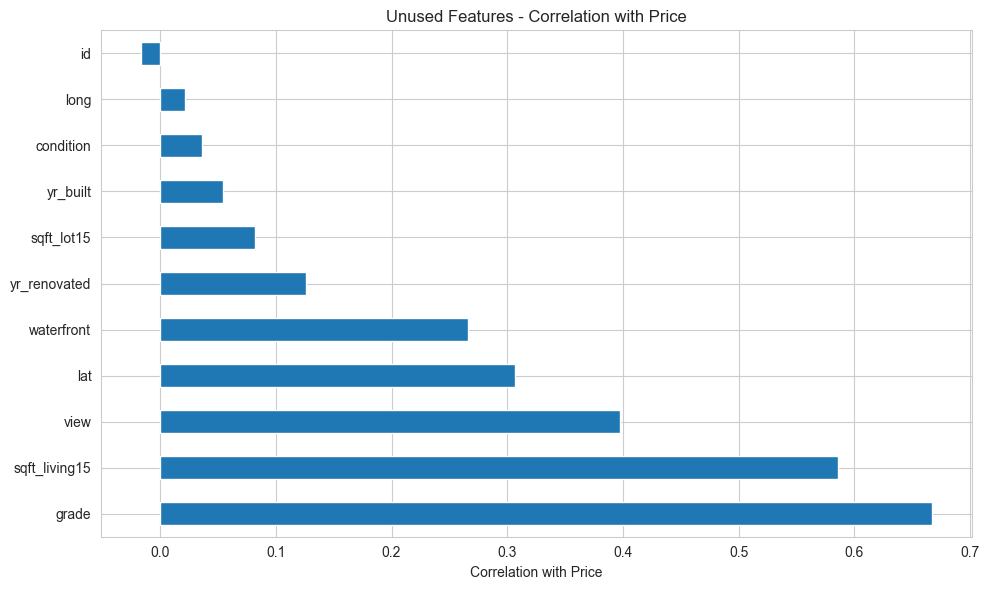

In [8]:
if 'price' in df_full.columns:
    numeric_unused = df_full[unused_features].select_dtypes(include=[np.number]).columns.tolist()
    
    if numeric_unused:
        correlations = df_full[numeric_unused + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
        
        print("\nCorrelation with price (unused features):")
        print(correlations)
        
        # Plot
        plt.figure(figsize=(10, 6))
        correlations.plot(kind='barh')
        plt.xlabel('Correlation with Price')
        plt.title('Unused Features - Correlation with Price')
        plt.tight_layout()
        plt.show()

## 5. Compare Used vs Unused Features

In [ ]:
numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numeric_cols:
    numeric_cols.remove('price')

all_correlations = df_full[numeric_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False)

print("Top 10 features by correlation with price:")
print(all_correlations.head(10))

print("\nBottom 10 features by correlation with price:")
print(all_correlations.tail(10))

Top 10 features by correlation with price:
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
Name: price, dtype: float64

Bottom 10 features by correlation with price:
lat             0.307003
waterfront      0.266369
floors          0.256794
yr_renovated    0.126434
sqft_lot        0.089661
sqft_lot15      0.082447
yr_built        0.054012
condition       0.036362
long            0.021626
id             -0.016762
Name: price, dtype: float64


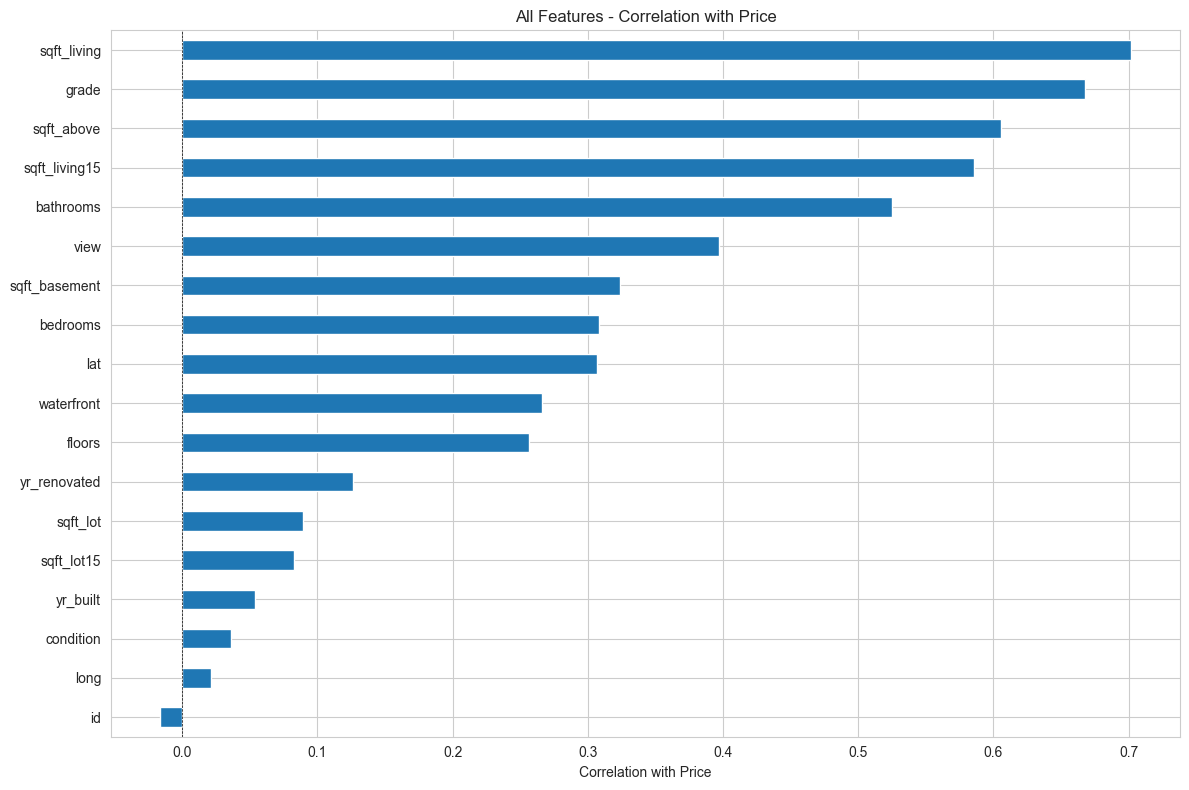

In [12]:
# Visualize all correlations
plt.figure(figsize=(12, 8))
all_correlations.sort_values().plot(kind='barh')
plt.xlabel('Correlation with Price')
plt.title('All Features - Correlation with Price')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Key Findings - What's Missing?

In [ ]:
numeric_unused = df_full[unused_features].select_dtypes(include=[np.number]).columns.tolist()

if numeric_unused and 'price' in df_full.columns:
    unused_corr = df_full[numeric_unused + ['price']].corr()['price'].drop('price').abs().sort_values(ascending=False)
    
    high_corr_unused = unused_corr[unused_corr > 0.31]  # Threshold: 0.3
    
    if len(high_corr_unused) > 0:
        print(" HIGH-CORRELATION FEATURES NOT USED BY MODEL:")
        print("These could improve model performance!\n")
        for feat, corr in high_corr_unused.items():
            print(f"  {feat}: {corr:.3f}")
    else:
        print("✓ No high-correlation features are missing")

 HIGH-CORRELATION FEATURES NOT USED BY MODEL:
These could improve model performance!

  grade: 0.667
  sqft_living15: 0.585
  view: 0.397


## 7. Recommendations for Model Improvement


### MODEL RECOMMENDATIONS

1. FEATURE ENGINEERING:
   - Add 'view' correlation with price likely high
   - Add 'condition' house condition matter
   - Add 'grade' construction qualit
   - Add 'waterfront' premium feature
   - Create 'house_age' = 2024 - yr_built
   - Create 'is_renovated' = 1 if yr_renovated > 0

2. MODEL SELECTION:
   - Current: KNN simple but limited
   - Improvement: Random Forest handles non-linearity bette
   - Reason: Better generalization, feature importance, less overfitting

3. REGULARIZATION:
   - Add max_depth to prevent overfitting
   - Use cross-validation to tune hyperparameters

4. VALIDATION:
   - Implement k-fold cross-validation
   - Check for overfitting train vs test performanc
   - Analyze residuals for patterns